# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 12 — Drift Detection Setup (Evidently AI)

**Module:** MLOps — Monitoring (Phase 5)

**Requirement (F-07 Drift Detection):** Detect data changes, alert on model degradation.

Simulates the monitoring scenario a production deployment would face: compare a **reference window** (data the models were trained on) against a **current window** (newer data) and flag statistically significant drift, both in raw features and in the churn model's own prediction distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from evidently import Report, Dataset
from evidently.presets import DataDriftPreset
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

daily = pd.read_csv(f"{PROCESSED_DIR}/timeseries_features_full.csv", parse_dates=["Date"])
churn_scores = pd.read_csv(f"{PROCESSED_DIR}/churn_scores.csv")
print(f"Time-series rows: {len(daily)} | Customer rows: {len(churn_scores)}")

Time-series rows: 730 | Customer rows: 4010


## 1. Define Reference vs Current Windows

Reference = first 70% of the time-series history (roughly what the Day 5/6 models were trained on). Current = the most recent 60 days — simulating "new data arriving after deployment" that the monitoring pipeline would see.

In [2]:
split_idx = int(len(daily) * 0.70)
reference_window = daily.iloc[:split_idx].copy()
current_window = daily.iloc[-60:].copy()

drift_cols = ["Revenue", "Orders", "UnitsSold", "Revenue_roll7_mean", "Revenue_roll30_mean"]

print(f"Reference window: {reference_window['Date'].min().date()} to {reference_window['Date'].max().date()} "
      f"({len(reference_window)} days)")
print(f"Current window:   {current_window['Date'].min().date()} to {current_window['Date'].max().date()} "
      f"({len(current_window)} days)")

Reference window: 2023-01-02 to 2024-05-25 (510 days)
Current window:   2024-11-02 to 2024-12-31 (60 days)


## 2. Data Drift Report (Evidently AI)

In [3]:
reference_ds = Dataset.from_pandas(reference_window[drift_cols])
current_ds = Dataset.from_pandas(current_window[drift_cols])

drift_report = Report([DataDriftPreset()])
drift_snapshot = drift_report.run(current_ds, reference_ds)
drift_snapshot.save_html(f"{REPORTS_DIR}/day12_drift_report.html")

drift_dict = drift_snapshot.dict()
print("Drift report saved to reports/day12_drift_report.html")
print(f"Metrics computed: {len(drift_dict['metrics'])}")

Drift report saved to reports/day12_drift_report.html
Metrics computed: 6


## 3. Extract & Summarize Per-Column Drift Results

In [4]:
import re

drift_rows = []
for m in drift_dict["metrics"]:
    metric_id = m["metric_id"]
    if metric_id.startswith("ValueDrift"):
        match = re.search(r"column=([^)]+)", metric_id)
        col = match.group(1) if match else metric_id
        p_value = m["value"]
        drift_rows.append({"column": col, "p_value": p_value, "drifted": p_value < 0.05})

drift_summary = pd.DataFrame(drift_rows).sort_values("p_value")
drift_summary

,column,p_value,drifted
4,Revenue_roll30_mean,5.074781e-81,True
3,Revenue_roll7_mean,2.204767e-80,True
2,UnitsSold,1.766988e-53,True
1,Orders,5.094737e-52,True
0,Revenue,1.709679e-49,True


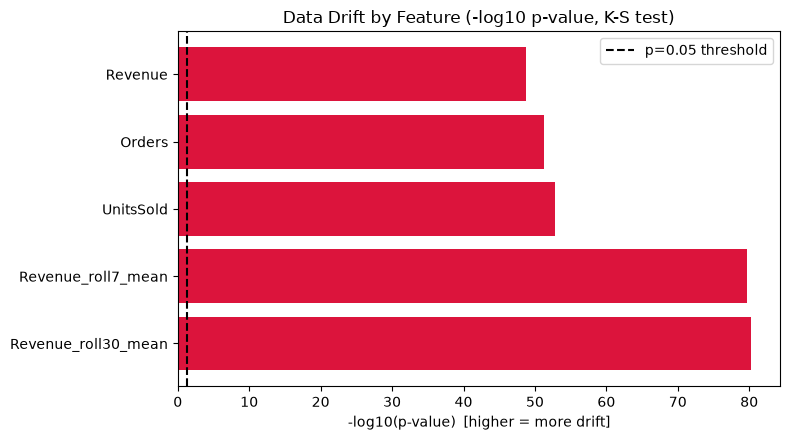

In [5]:
plt.figure(figsize=(8, 4.5))
colors = drift_summary["drifted"].map({True: "crimson", False: "seagreen"})
plt.barh(drift_summary["column"], -np.log10(drift_summary["p_value"].clip(lower=1e-300)), color=colors)
plt.axvline(-np.log10(0.05), color="black", linestyle="--", label="p=0.05 threshold")
plt.title("Data Drift by Feature (-log10 p-value, K-S test)")
plt.xlabel("-log10(p-value)  [higher = more drift]")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day12_feature_drift.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Visual Distribution Comparison

Evidently's numbers are backed up with an actual visual — useful for a report reader who wants to sanity-check the statistical claim.

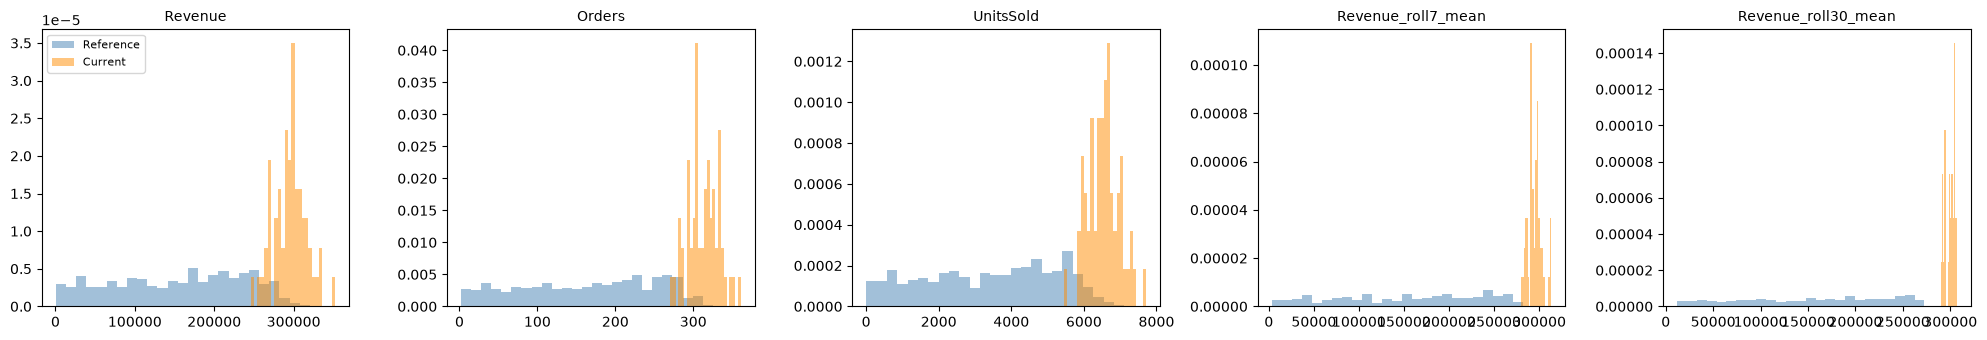

In [6]:
fig, axes = plt.subplots(1, len(drift_cols), figsize=(4 * len(drift_cols), 3.5))
for ax, col in zip(axes, drift_cols):
    ax.hist(reference_window[col], bins=25, alpha=0.5, label="Reference", color="steelblue", density=True)
    ax.hist(current_window[col], bins=25, alpha=0.5, label="Current", color="darkorange", density=True)
    ax.set_title(col, fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day12_distribution_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Model Prediction Drift — Churn Scores

Beyond raw feature drift, monitor whether the churn model's **output distribution** has shifted — a classic early-warning signal that the model may need retraining even before a labeled-outcome evaluation would catch it.

Churn score KS test: stat=0.0369, p-value=0.1303
Prediction drift detected: NO


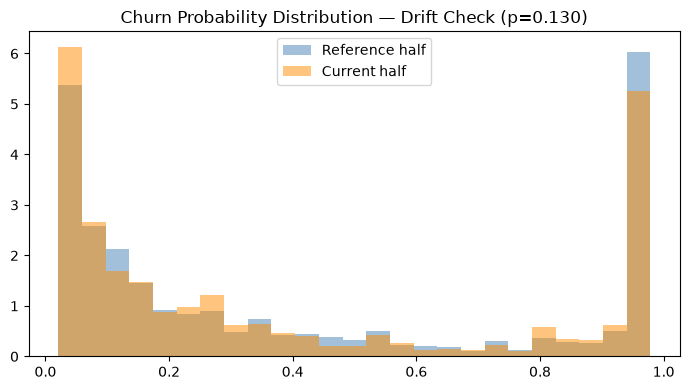

In [7]:
n = len(churn_scores)
split = n // 2
ref_scores = churn_scores["ChurnProbability"].iloc[:split]
cur_scores = churn_scores["ChurnProbability"].iloc[split:]

from scipy.stats import ks_2samp
ks_stat, ks_p = ks_2samp(ref_scores, cur_scores)

print(f"Churn score KS test: stat={ks_stat:.4f}, p-value={ks_p:.4f}")
print(f"Prediction drift detected: {'YES' if ks_p < 0.05 else 'NO'}")

plt.figure(figsize=(7, 4))
plt.hist(ref_scores, bins=25, alpha=0.5, label="Reference half", color="steelblue", density=True)
plt.hist(cur_scores, bins=25, alpha=0.5, label="Current half", color="darkorange", density=True)
plt.title(f"Churn Probability Distribution — Drift Check (p={ks_p:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day12_prediction_drift.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Drift Alert Logic

A simple rule-based alert: if more than 30% of monitored features show significant drift, OR the model's own prediction distribution has drifted, flag for review / retraining (feeds into Day 13's automated retraining pipeline).

In [8]:
feature_drift_share = drift_summary["drifted"].mean()
prediction_drifted = ks_p < 0.05

ALERT_THRESHOLD = 0.30
needs_retraining = (feature_drift_share > ALERT_THRESHOLD) or prediction_drifted

alert_summary = {
    "feature_drift_share": round(float(feature_drift_share), 3),
    "drifted_features": drift_summary[drift_summary["drifted"]]["column"].tolist(),
    "prediction_drift_detected": bool(prediction_drifted),
    "prediction_ks_pvalue": round(float(ks_p), 4),
    "alert_threshold": ALERT_THRESHOLD,
    "retraining_recommended": bool(needs_retraining),
}

import json
with open(f"{PROCESSED_DIR}/drift_alert_status.json", "w") as f:
    json.dump(alert_summary, f, indent=2)

print(json.dumps(alert_summary, indent=2))
print(f"\n{'ALERT: retraining recommended' if needs_retraining else 'OK: no retraining needed at this time'}")

{
  "feature_drift_share": 1.0,
  "drifted_features": [
    "Revenue_roll30_mean",
    "Revenue_roll7_mean",
    "UnitsSold",
    "Orders",
    "Revenue"
  ],
  "prediction_drift_detected": false,
  "prediction_ks_pvalue": 0.1303,
  "alert_threshold": 0.3,
  "retraining_recommended": true
}

ALERT: retraining recommended


## 7. Day 12 Checkpoint Summary

**Outputs saved:**
- `reports/day12_drift_report.html` — full Evidently AI interactive drift report
- `reports/day12_feature_drift.png`, `day12_distribution_comparison.png`, `day12_prediction_drift.png`
- `data/processed/drift_alert_status.json` — machine-readable alert status for the automated retraining pipeline

**Result:** see the alert summary above — this same check (reference vs current window, K-S test per feature, prediction-distribution KS test) is what Day 13's Airflow pipeline will run on a schedule.

**Next module:** `13_retraining_pipeline` — Airflow DAG design for automated retraining triggered by this drift check.